In [2]:
!git clone https://github.com/vrdn-23/SemEval-2020

Cloning into 'SemEval-2020'...
remote: Enumerating objects: 2268, done.
remote: Counting objects: 100% (2268/2268), done.
remote: Compressing objects: 100% (1494/1494), done.
remote: Total 2268 (delta 735), reused 2200 (delta 695), pack-reused 0 (from 0)
Receiving objects: 100% (2268/2268), 9.97 MiB | 11.03 MiB/s, done.
Resolving deltas: 100% (735/735), done.


In [3]:
from pathlib import Path

base_path = Path("SemEval-2020/datasets")

articles_path = base_path / "train-articles"
si_labels_path = base_path / "train-labels-task1-span-identification"

articles = {}
for txt in articles_path.glob("*.txt"):
    article_id = txt.stem.replace("article", "")
    articles[article_id] = txt.read_text(encoding="utf-8")

si_labels = {}
for label in si_labels_path.glob("*.labels"):
    article_id = label.stem.replace("article", "").replace(".task1-SI", "")
    spans = []
    for line in label.read_text(encoding="utf-8").splitlines():
        _, start, end = line.split("\t")
        spans.append((int(start), int(end)))
    si_labels[article_id] = spans

In [4]:
import re

token_pattern = re.compile(r"\w+|[^\w\s]")

def tokenize_and_label(text, spans):
    tokens, labels = [], []

    for match in re.finditer(token_pattern, text):
        token = match.group()
        start, end = match.span()

        label = "O"
        for s, e in spans:
            if start >= s and start < e:
                label = "B" if start == s else "I"
                break

        tokens.append(token)
        labels.append(label)

    return tokens, labels

In [5]:
from datasets import Dataset

data = []
for article_id, text in articles.items():
    spans = si_labels.get(article_id, [])
    tokens, labels = tokenize_and_label(text, spans)
    data.append({"tokens": tokens, "labels": labels})

dataset = Dataset.from_list(data)

In [6]:
split = dataset.train_test_split(test_size=0.1, seed=42)
train_data = split["train"]
eval_data = split["test"]

In [10]:
for example in train_data.select(range(5)):
    print("tokens:", example["tokens"])
    print("labels:", example["labels"])
    print()

tokens: ['France', 'Gives', 'Muslim', 'Killer', 'of', 'Elderly', 'Jewish', 'Woman', 'a', 'Pass', 'Every', 'other', 'Muslim', 'terrorist', 'or', 'killer', 'in', 'Europe', 'has', 'his', 'actions', 'blamed', 'on', 'mental', 'illness', 'or', 'drug', 'use', '.', 'This', 'just', 'continues', 'the', 'pattern', '.', 'I', 'wrote', 'about', 'the', 'murder', 'of', 'Sarah', 'Halimi', 'last', 'year', '.', 'Sarah', 'Lucy', 'Halimi', 'was', 'thrown', 'out', 'of', 'the', 'window', 'of', 'the', 'third', 'floor', 'Paris', 'apartment', 'while', 'she', 'begged', 'her', 'Muslim', 'killer', 'to', 'spare', 'her', 'life', '.', 'The', '66', '-', 'year', '-', 'old', 'director', 'of', 'an', 'Orthodox', 'Jewish', 'nursery', 'was', 'woken', 'from', 'her', 'sleep', 'when', 'she', 'was', 'violently', 'beaten', 'by', 'her', 'twenty', 'something', 'Muslim', 'neighbor', 'who', 'then', 'dragged', 'her', 'to', 'the', 'window', '.', 'She', 'died', 'on', 'the', 'street', 'outside', 'the', 'building', 'where', 'she', 'had',

##Qwen3-235B-A22B: zero-shot & few-shot settings

In [6]:
import openai
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import re
from tqdm.notebook import tqdm
import json

In [7]:
with open("vars.json", "r") as fin:
  YANDEX_CLOUD_FOLDER = json.load(fin)["folder_id"]
with open("key.json", "r") as fin:
  YANDEX_CLOUD_API_KEY = json.load(fin)["key"]
with open("model.json", "r") as fin:
  YANDEX_CLOUD_MODEL = json.load(fin)["model"]
with open("url.json", "r") as fin:
  base_url = json.load(fin)["url"]

In [8]:
client = openai.OpenAI(
  api_key=YANDEX_CLOUD_API_KEY,
  base_url=base_url,
  project=YANDEX_CLOUD_FOLDER
)

In [9]:
def flatten_labels(preds, golds):
  pred_flat = [l for seq in preds for l in seq]
  gold_flat = [l for seq in golds for l in seq]
  return pred_flat, gold_flat

true_preds = [s["labels"] for s in eval_data]

In [10]:
def clean_labels(labels, n_tokens):
    labels = [l.strip() for l in labels if l.strip() in {"B", "I", "O"}]
    if len(labels) > n_tokens:
        labels = labels[:n_tokens]
    elif len(labels) < n_tokens:
        labels += ["O"] * (n_tokens - len(labels))
    return labels

In [11]:
def compute_metrics(pred_labels, true_labels):
  return {
      "accuracy": accuracy_score(true_labels, pred_labels),
      "P": precision_score(true_labels, pred_labels, average="macro", zero_division=0),
      "R": recall_score(true_labels, pred_labels, average="macro", zero_division=0),
      "F1": f1_score(true_labels, pred_labels, average="macro", zero_division=0)
  }

###zero-shot

In [12]:
def predict_zero_shot(tokens):
  prompt = f"""
You are a propaganda detection assistant.
Your task is to perform token-level labeling using the BIO format to detect propaganda.
Each token may or may not relate to a propaganda.
- Label each token as B if it is the beginning of a propaganda fragment.
- Label as I if it is inside a propaganda fragment.
- Label as O if it is outside a propaganda fragment (not propaganda at all).
Return ONLY a list of labels in the same order as the tokens, separated by spaces.

Tokens: {" ".join(tokens)}

Labels:
"""
  response = client.responses.create(
      model=f"gpt://{YANDEX_CLOUD_FOLDER}/{YANDEX_CLOUD_MODEL}",
      temperature=0,
      instructions="Label tokens using BIO scheme to detect propaganda in news.",
      input=prompt,
      max_output_tokens=500
  )

  output = response.output_text.strip()
  return re.split(r"\s+", output)

In [13]:
pred_zero = []
for sample in tqdm(eval_data):
  pred_labels = predict_zero_shot(sample["tokens"])
  pred_labels = clean_labels(pred_labels, len(sample["tokens"]))
  pred_zero.append(pred_labels)

  0%|          | 0/38 [00:00<?, ?it/s]

In [14]:
pred_zero_flat, true_zero_flat = flatten_labels(pred_zero, true_preds)
metrics_zero = compute_metrics(pred_zero_flat, true_zero_flat)

print("Zero-Shot Metrics:")
print(metrics_zero)
print(classification_report(true_zero_flat, pred_zero_flat, zero_division=0))

Zero-Shot Metrics:
{'accuracy': 0.6269787133952722, 'P': 0.33095321056975413, 'R': 0.3152714905851178, 'F1': 0.3049149458445966}
              precision    recall  f1-score   support

           B       0.03      0.00      0.00       511
           I       0.10      0.25      0.15      5255
           O       0.86      0.69      0.76     36749

    accuracy                           0.63     42515
   macro avg       0.33      0.32      0.30     42515
weighted avg       0.75      0.63      0.68     42515



###few-shot

In [8]:
def build_fewshot_prompt(examples, instruction=None):
  prompt = """You are a propaganda detection assistant.
Your task is to perform token-level labeling using the BIO format to detect propaganda.
Each token may or may not relate to a propaganda.
- Label each token as B if it is the beginning of a propaganda fragment.
- Label as I if it is inside a propaganda fragment.
- Label as O if it is outside a propaganda fragment (not propaganda at all).
Return ONLY a list of labels in the same order as the tokens, separated by spaces.\n\nHere are some examples:\n"""
  for ex in examples:
    prompt += f"Tokens: {' '.join(ex['tokens'])}\nLabels: {' '.join(ex['labels'])}\n"
  prompt += "\nNow, label the following tokens:\n"
  return prompt

def predict_few_shot(tokens, examples, show_prompt=True):
  prompt = build_fewshot_prompt(examples) + f"Tokens: {' '.join(tokens)}\nLabels:"

  response = client.responses.create(
      model=f"gpt://{YANDEX_CLOUD_FOLDER}/{YANDEX_CLOUD_MODEL}",
      temperature=0,
      instructions="Label tokens using BIO scheme to detect propaganda in news.",
      input=prompt,
      max_output_tokens=500
    )
  output = response.output_text.strip()
  return re.split(r"\s+", output)

In [9]:
print(build_fewshot_prompt([train_data[i] for i in range(2)]))

You are a propaganda detection assistant.
Your task is to perform token-level labeling using the BIO format to detect propaganda.
Each token may or may not relate to a propaganda.
- Label each token as B if it is the beginning of a propaganda fragment.
- Label as I if it is inside a propaganda fragment.
- Label as O if it is outside a propaganda fragment (not propaganda at all).
Return ONLY a list of labels in the same order as the tokens, separated by spaces.

Here are some examples:
Tokens: France Gives Muslim Killer of Elderly Jewish Woman a Pass Every other Muslim terrorist or killer in Europe has his actions blamed on mental illness or drug use . This just continues the pattern . I wrote about the murder of Sarah Halimi last year . Sarah Lucy Halimi was thrown out of the window of the third floor Paris apartment while she begged her Muslim killer to spare her life . The 66 - year - old director of an Orthodox Jewish nursery was woken from her sleep when she was violently beaten by

In [25]:
example_counts = [1, 3, 5, 10] #количество примеров во фью-шоте
results = {}

for n in example_counts:
  few_shot_examples = [train_data[i] for i in range(n)]
  pred_labels_all = []
  true_labels_all = []

  for sample in tqdm(eval_data):
      pred_labels = predict_few_shot(sample["tokens"], few_shot_examples)
      pred_labels = clean_labels(pred_labels, len(sample["tokens"]))
      pred_labels_all.append(pred_labels)
      true_labels_all.append(sample["labels"])

  pred_flat, true_flat = flatten_labels(pred_labels_all, true_labels_all)

  metrics = compute_metrics(pred_flat, true_flat)
  print(f"\n{n}-Shot metrics:")
  print(metrics)
  print(classification_report(true_flat, pred_flat, zero_division=0))

  0%|          | 0/38 [00:00<?, ?it/s]


1-Shot metrics:
{'accuracy': 0.7073973891567682, 'P': 0.3416408071313606, 'R': 0.33274775573515536, 'F1': 0.32735210715935903}
              precision    recall  f1-score   support

           B       0.04      0.00      0.00       511
           I       0.12      0.21      0.15      5255
           O       0.87      0.79      0.83     36749

    accuracy                           0.71     42515
   macro avg       0.34      0.33      0.33     42515
weighted avg       0.76      0.71      0.73     42515



  0%|          | 0/38 [00:00<?, ?it/s]


3-Shot metrics:
{'accuracy': 0.7458073621074914, 'P': 0.3311549672981698, 'R': 0.31592178369004675, 'F1': 0.3155168416162543}
              precision    recall  f1-score   support

           B       0.05      0.00      0.00       511
           I       0.08      0.10      0.09      5255
           O       0.86      0.85      0.85     36749

    accuracy                           0.75     42515
   macro avg       0.33      0.32      0.32     42515
weighted avg       0.75      0.75      0.75     42515



  0%|          | 0/38 [00:00<?, ?it/s]


5-Shot metrics:
{'accuracy': 0.7323768081853463, 'P': 0.3277710794060465, 'R': 0.33097392580039786, 'F1': 0.32771104210324997}
              precision    recall  f1-score   support

           B       0.00      0.00      0.00       511
           I       0.12      0.17      0.14      5255
           O       0.86      0.82      0.84     36749

    accuracy                           0.73     42515
   macro avg       0.33      0.33      0.33     42515
weighted avg       0.76      0.73      0.75     42515



  0%|          | 0/38 [00:00<?, ?it/s]


10-Shot metrics:
{'accuracy': 0.7456897565565095, 'P': 0.30943501359316966, 'R': 0.31104738027180673, 'F1': 0.310134778866547}
              precision    recall  f1-score   support

           B       0.00      0.00      0.00       511
           I       0.07      0.08      0.08      5255
           O       0.86      0.85      0.85     36749

    accuracy                           0.75     42515
   macro avg       0.31      0.31      0.31     42515
weighted avg       0.75      0.75      0.75     42515



###visualization


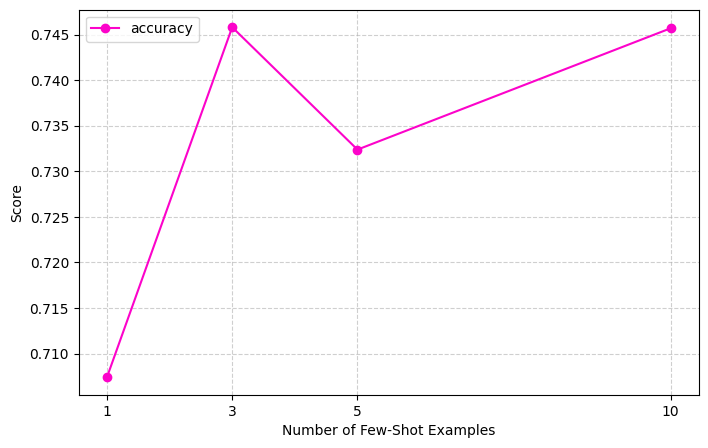

In [35]:
#качество в зависимости от количества примеров во фью-шоте

# metrics_names = ["accuracy", "P", "R", "F1"]
metrics_names = ["accuracy"]
metrics_values = {m: [results[n][m] for n in example_counts] for m in metrics_names}

plt.figure(figsize=(8,5))

for metric in metrics_names:
  plt.plot(example_counts, metrics_values[metric], marker='o', label=metric, color = "#fc03ca")

plt.xticks(example_counts)
plt.xlabel("Number of Few-Shot Examples")
plt.ylabel("Score")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

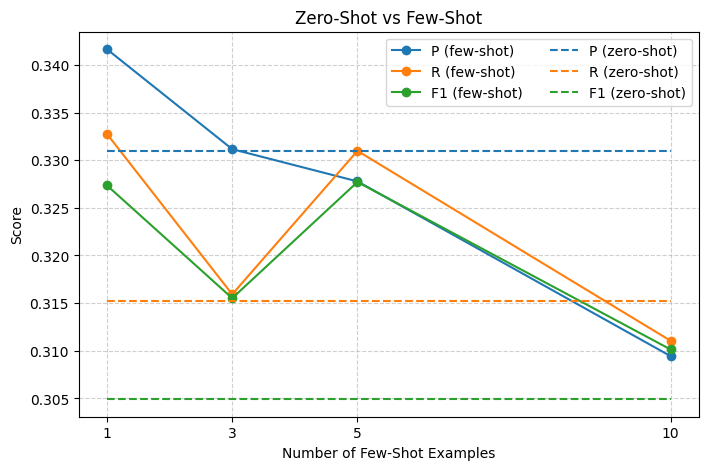

In [41]:
# сравнение few-shot (all) vs zero-shot
metrics_names = ["P", "R", "F1"]
metrics_values = {m: [results[n][m] for n in example_counts] for m in metrics_names}

plt.figure(figsize=(8,5))

colors = {}
for metric in metrics_names:
    line, = plt.plot(example_counts, metrics_values[metric], marker='o', label=f"{metric} (few-shot)")
    colors[metric] = line.get_color()

for metric in metrics_names:
    plt.hlines(
        y=metrics_zero[metric],
        xmin=min(example_counts),
        xmax=max(example_counts),
        colors=colors[metric],
        linestyles='dashed',
        label=f"{metric} (zero-shot)"
    )

plt.xticks(example_counts)
plt.xlabel("Number of Few-Shot Examples")
plt.ylabel("Score")
plt.title("Zero-Shot vs Few-Shot")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(ncol=2)
plt.show()